# <font color='blue'>PRACTICA PDI 10</font>

### 1. Detección de contornos

Detecte bordes en una imagen que tenga distitas formas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

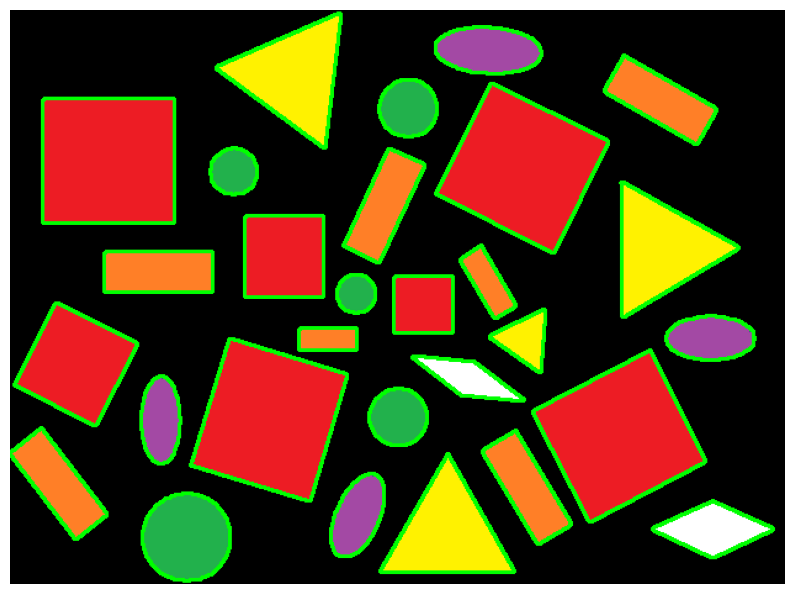

In [2]:
#Documentación https://docs.opencv.org/trunk/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0

imc = cv2.imread('lab_images/formas.png')
img = cv2.cvtColor(imc, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(img, 10, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

cv2.drawContours(imc, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(imc, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


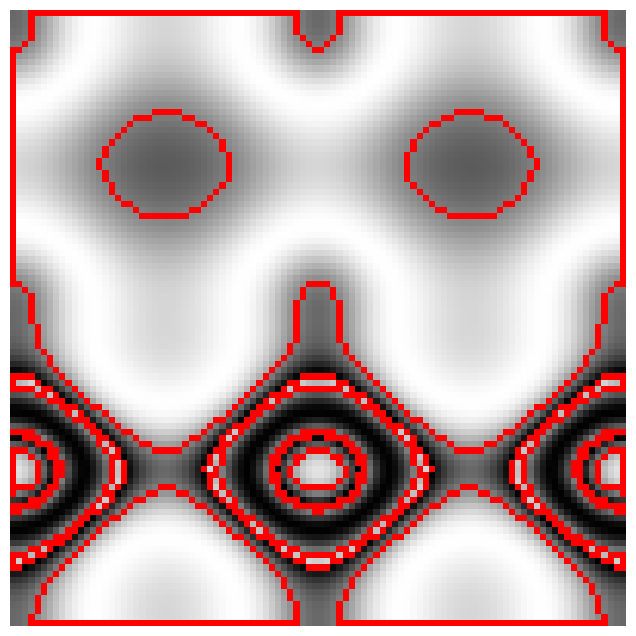

In [5]:
x, y = np.ogrid[-np.pi:np.pi:100j, -np.pi:np.pi:100j]
r = np.sin(np.exp((np.sin(x)**3 + np.cos(y)**2))) * 255
r = np.uint8(r)

out = np.zeros((100, 100, 3), np.uint8)
out[..., 0] = r
out[..., 1] = r
out[..., 2] = r

_, thresh = cv2.threshold(r, 125, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(
    thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
)

cv2.drawContours(out, contours, -1, (0, 0, 255), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

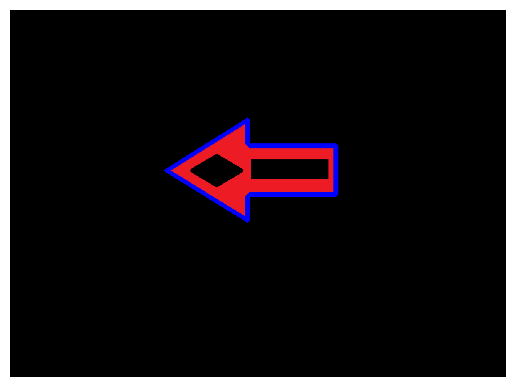

In [8]:
a = cv2.imread("lab_images/flecha.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(a, contours, -1, (255,0,0), 4)

plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### 2. Suavizado de poligonos y aproximacion poligonal
* aproxime un poligono para la figura "cordiode.tif"


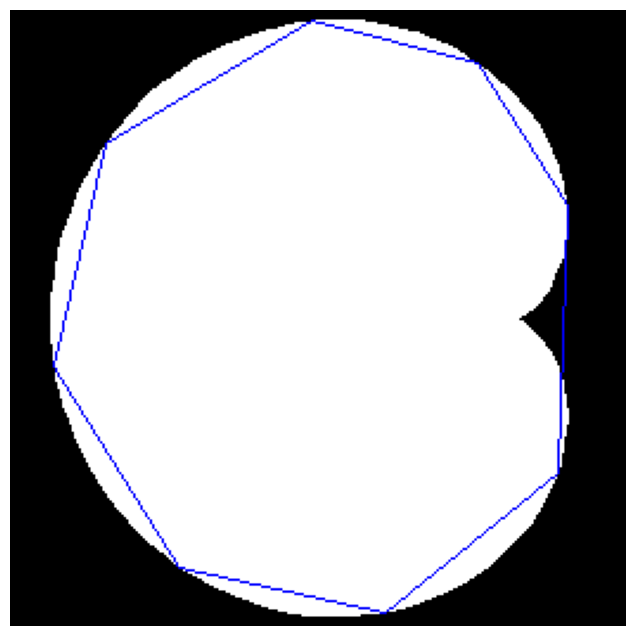

In [29]:
#https://docs.opencv.org/3.4/dd/d49/tutorial_py_contour_features.html
a = cv2.imread("lab_images/cardiode.tif")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

pts = cv2.approxPolyDP(contours[0], 20, True)


cv2.polylines(a, [pts], True, (255,0,0))

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

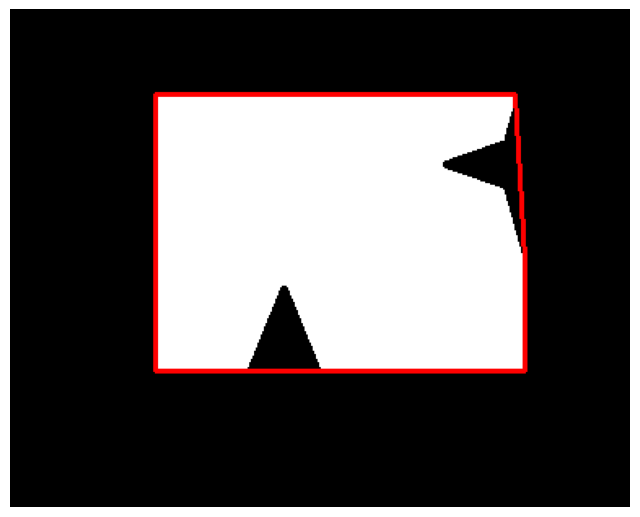

In [36]:
a = cv2.imread("lab_images/irregular.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
cnt, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

hull = cv2.convexHull(cnt[0])

cv2.drawContours(a, [hull], -1, (0,0,255), 2)
# cv2.polylines(a, [hull], True, (255,0,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


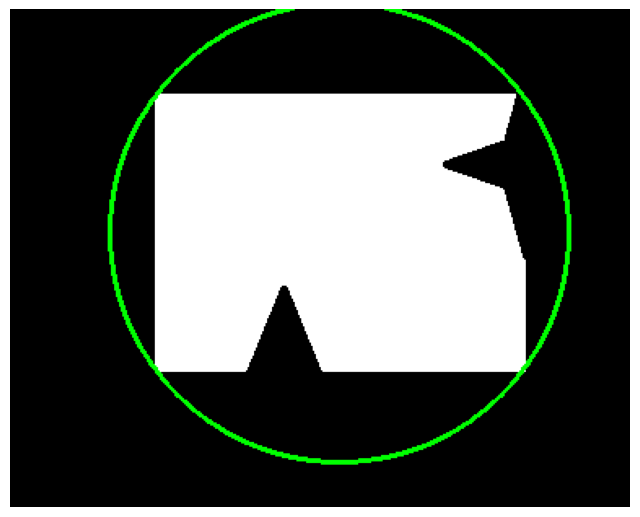

In [39]:
#Circulo minimo de encierre
import cv2
import matplotlib.pyplot as plt

a = cv2.imread("lab_images/irregular.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
cnt, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

(x, y), radius = cv2.minEnclosingCircle(cnt[0])

center = (int(x), int(y))
radius = int(radius)

cv2.circle(a, center, radius, (0,255,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


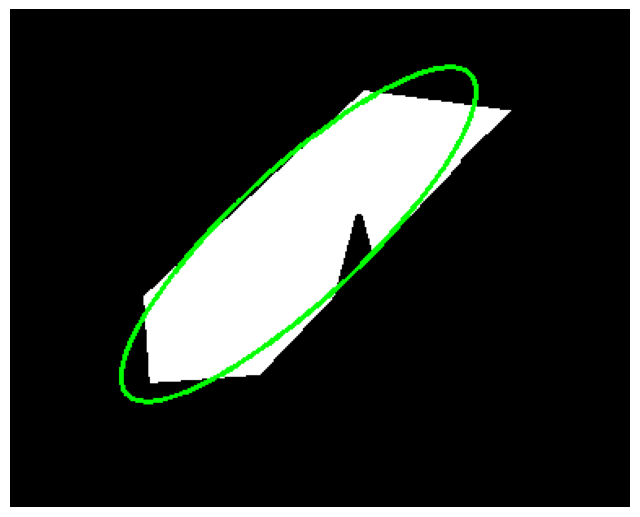

In [40]:
#Encajado con una elipse
a = cv2.imread("lab_images/irregulard.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
cnt, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

elip = cv2.fitEllipse(cnt[0])

cv2.ellipse(a, elip, (0,255,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


### 3. Obtención de descriptores de regiones
* Obtenga las propiedades de region disponibles en OpenCv

El perimetro es: 777.7442942857742
El area es: 23685.0 ó 23685.0
La circularidad es: 25.538787726159047


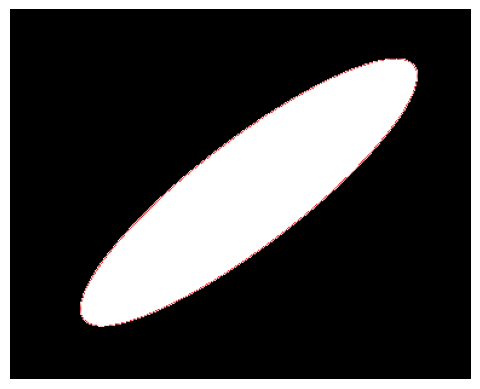

In [42]:
a = cv2.imread("lab_images/elipsed.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
cnt, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Propiedades
M = cv2.moments(cnt[0])
perimeter = cv2.arcLength(cnt[0], True)
area = cv2.contourArea(cnt[0])

circ = perimeter**2 / area

print(f"El perimetro es: {perimeter}")
print(f"El area es: {M['m00']} ó {area}")
print(f"La circularidad es: {circ}")

plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

La relacion de aspecto es: 1.2567567567567568
La extension es: 0.3823985275598179


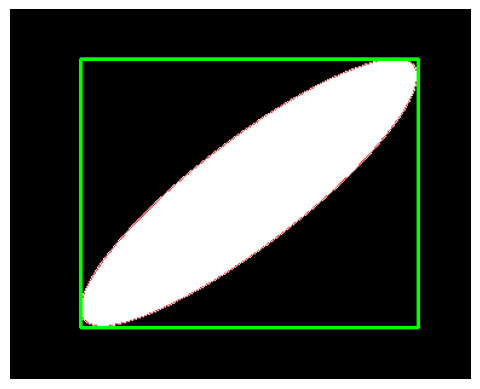

In [43]:
x, y, w, h = cv2.boundingRect(ag)
cv2.rectangle(a, (x, y), (x + w, y + h), (0,255,0), 2)

aspect_ratio = float(w) / h
print(f"La relacion de aspecto es: {aspect_ratio}")

extent = area / (w * h)
print(f"La extension es: {extent}")

plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

La inclinacion de la elipse es: 53.13010025024414


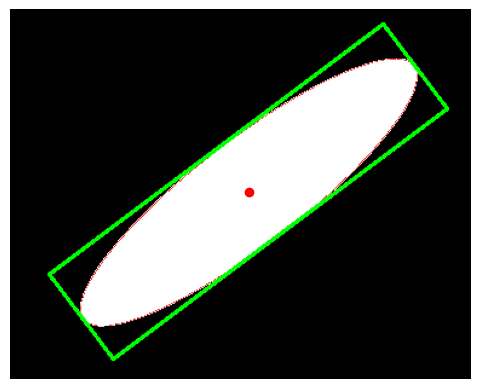

In [46]:
#RECTANGULO MINIMO
a = cv2.imread("lab_images/elipsed.png")

rect = cv2.minAreaRect(cnt[0])
box = cv2.boxPoints(rect)
box = np.int32(box)
cv2.drawContours(a, [box], 0, (0,255,0), 2)

print(f"La inclinacion de la elipse es: {rect[2]}")

plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.plot(197,151, marker="o", color="red")
plt.axis("off")
plt.show()

In [49]:
#Area del Rectangulo mínimo
AR = rect[1][0]*rect[1][1]
print(AR)

30446.640023193322


In [50]:
#RECTANGULARIDAD
rect = area/AR

print(rect)

0.7779183509890579


La solidez es: 95.67529741077678


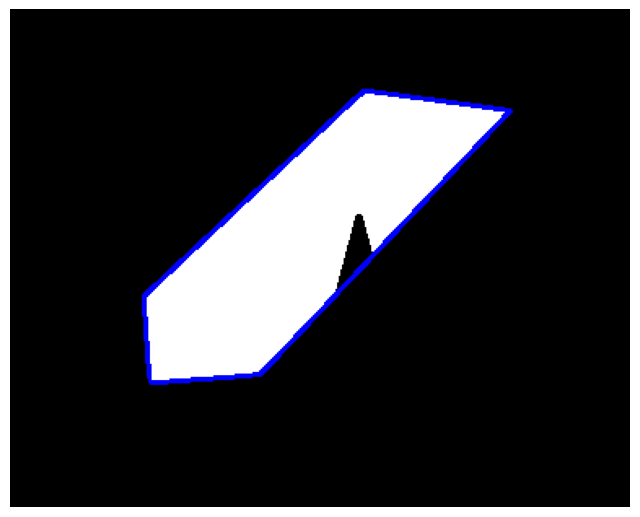

In [51]:
a = cv2.imread("lab_images/irregulard.png")
ag = cv2.cvtColor(a, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(ag, 10, 255, cv2.THRESH_BINARY)
cnt, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

hull = cv2.convexHull(cnt[0])
hull_area = cv2.contourArea(hull)
cv2.polylines(a, [hull], True, (255,0,0), 2)

momen = cv2.moments(cnt[0])
solidity = momen["m00"] / hull_area
print(f"La solidez es: {solidity*100}")

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [53]:
#Diametro equivalente a una circunferencia
equi_diameter = np.sqrt(4*momen["m00"]/np.pi)
print(f"El diametro del circulo con area equivalente es: {equi_diameter}")

El diametro del circulo con area equivalente es: 147.5115718156509


### 4. Propiedades de conjuntos de figuras
* Obtenga las propiedades de varias regiones en simultaneo

El numero de regiones es:  5


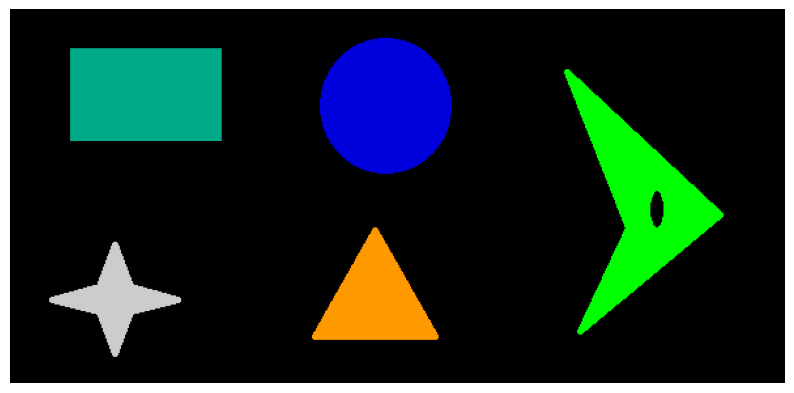

In [54]:
im = cv2.imread("lab_images/formas2.png")
img = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

_, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

num_labels, im_label = cv2.connectedComponents(img_bin)

print("El numero de regiones es: ", num_labels - 1)

plt.figure(figsize=(10,5))
plt.imshow(im_label, cmap="nipy_spectral")
plt.axis("off")
plt.show()


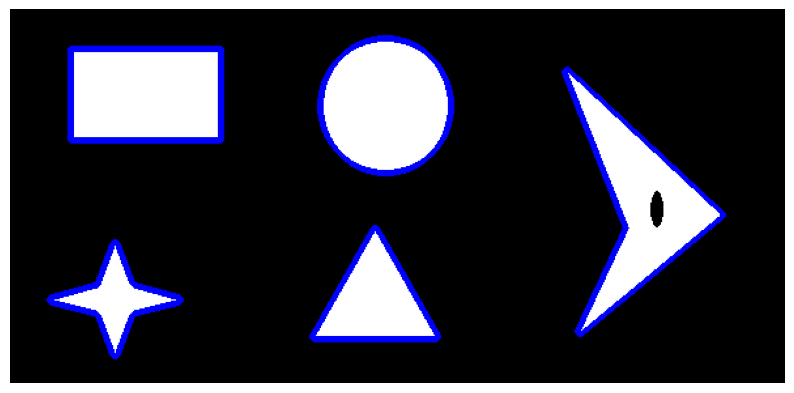

In [57]:
cnt, hierarchy = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

cv2.drawContours(im, cnt, -1, (255,0,0), 4)

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [58]:
momentos = []
perimetros = []
areas = []
circularidades = []
centroides = []

for c in cnt:
    m = cv2.moments(c)

    area = cv2.contourArea(c)
    perimetro = cv2.arcLength(c, True)

    # Circularidad clásica
    if perimetro > 0:
        circ = 4 * np.pi * area / (perimetro ** 2)
    else:
        circ = 0

    if m["m00"] != 0:
        cx = int(m["m10"] / m["m00"])
        cy = int(m["m01"] / m["m00"])
    else:
        cx, cy = 0, 0

    momentos.append(m)
    perimetros.append(perimetro)
    areas.append(area)
    circularidades.append(circ)
    centroides.append((cx, cy))

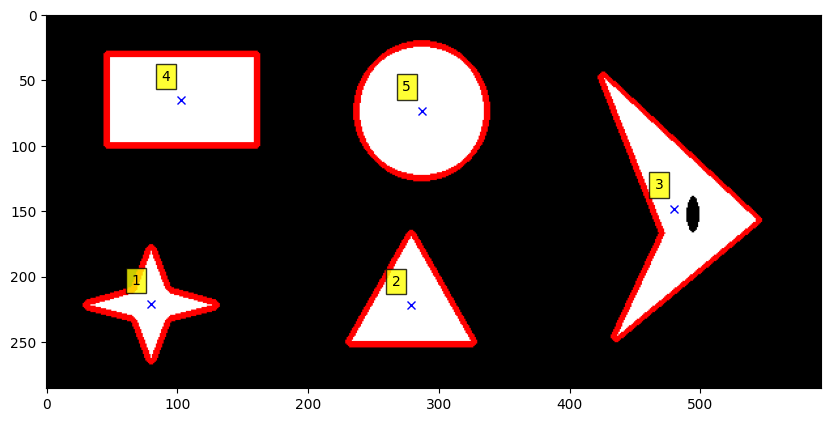

In [61]:
#ETIQUETADO DE COMPONENTES
plt.figure(figsize=(10,5))
plt.imshow(im)

for i, centroide in enumerate(centroides):
    txt = str(i+1)
    x = centroide[0]
    y = centroide[1]
    plt.plot(x, y, marker="x", color="blue")
    plt.text(x-15, y-15, txt, bbox=dict(facecolor='yellow', alpha=0.8))

plt.show()

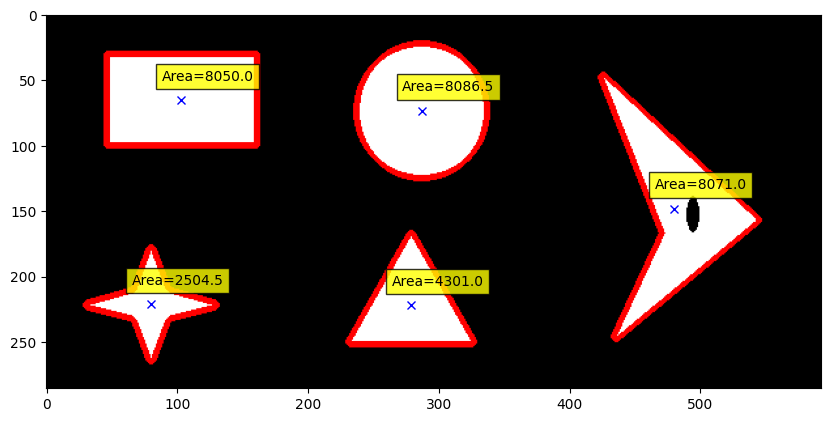

In [62]:
#ETIQUETANDO CON PROPIEDADES ESPECIFICAS
plt.figure(figsize=(10,5))
plt.imshow(im)

for i, centroide in enumerate(centroides):
    txt = "Area="+str(areas[i])
    x = centroide[0]
    y = centroide[1]
    plt.plot(x, y, marker="x", color="blue")
    plt.text(x-15,y-15,txt,bbox=dict(facecolor='yellow', alpha=0.8))
plt.show()

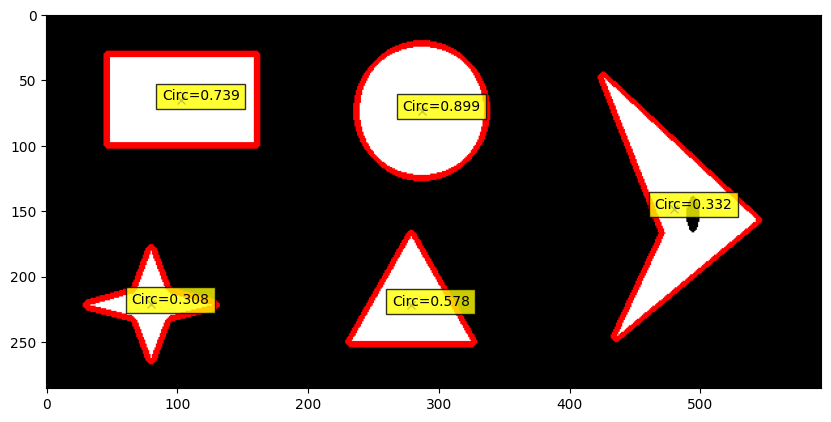

In [63]:
plt.figure(figsize=(10,5))
plt.imshow(im)
for i, centroide in enumerate(centroides):
    txt = "Circ="+str(np.round(circularidades[i],3))
    x = centroide[0]
    y = centroide[1]
    plt.plot(x, y, marker="x", color="blue")
    plt.text(x-15,y,txt,bbox=dict(facecolor='yellow', alpha=0.8))
plt.show()

### 5. Momentos invariantes de Hu
A una imagen en escala de grises, rotela, escalela, trasladela y luego compruebe la invarianza de los momentos de Hu

In [64]:
img = cv2.imread("lab_images/AI.jpg",0)

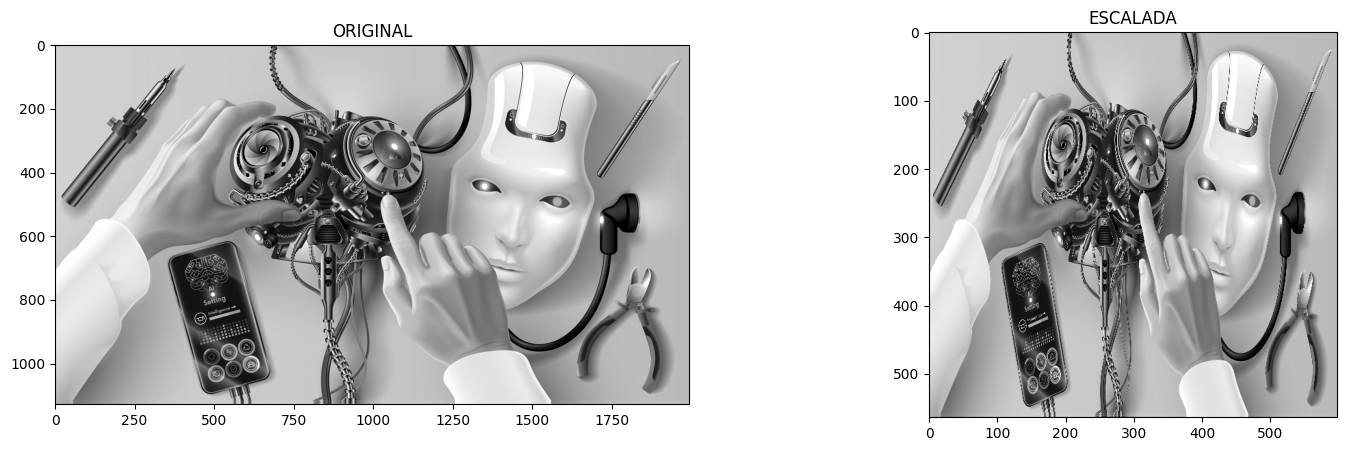

In [65]:
#Escalado
img_res = cv2.resize(img,None,fx=0.3, fy=0.5, interpolation = cv2.INTER_CUBIC)

plt.figure(figsize=(18,5))
plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("ORIGINAL")
plt.subplot(122)
plt.imshow(img_res, cmap="gray")
plt.title("ESCALADA")
plt.show()

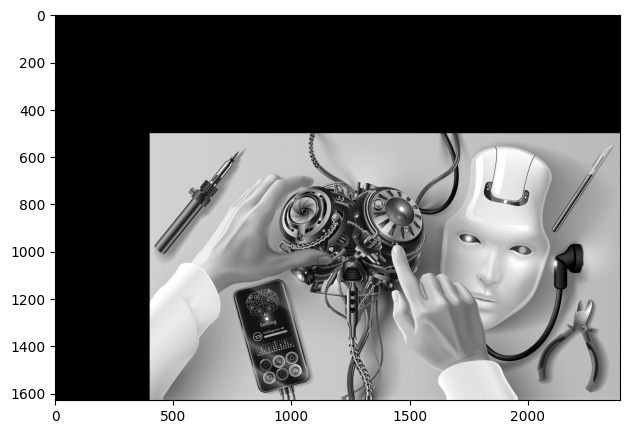

In [66]:
#Traslación
tr = 500
tc = 400
rows,cols = img.shape

img_trasl = np.zeros((rows+tr,cols+tc))
img_trasl[tr:,tc:] = img

plt.figure(figsize=(15,5))
plt.imshow(img_trasl, cmap="gray")
plt.show()

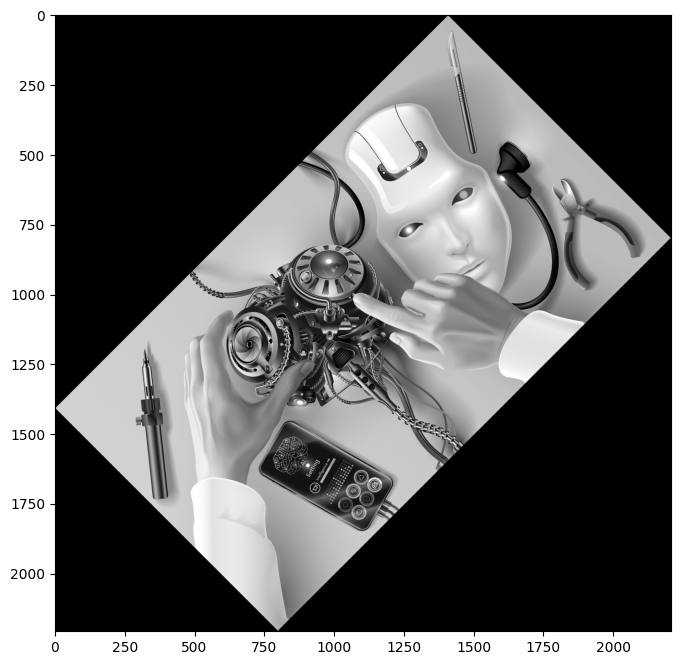

In [67]:
#Rotación
from scipy import ndimage

img_rot = ndimage.rotate(img, 45, reshape=True)

plt.figure(figsize=(18,8))
plt.imshow(img_rot, cmap="gray")
plt.show()

In [ ]:
#MOMENTOS DE HU
im = [img, img_res, img_rot, img_trasl]

huMoments_full = []

for img in im:
    moments = cv2.moments(img)

    huMoments = cv2.HuMoments(moments)

    for i in range(7):
        huMoments[i] = np.round(-1* np.sign(huMoments[i]) * np.log10(np.abs(huMoments[i])),3)

    huMoments_full.append(huMoments)

In [70]:
lab = ["ORIGINAL: ", "ESCALADA: ", "ROTADA: ", "TRASLADADA: "]

print("MOMENTOS INVARIANTES DE HU\n")

for i in range(len(huMoments_full)):
    print(lab[i])
    print(huMoments_full[i][0],
          huMoments_full[i][1],
          huMoments_full[i][2],
          huMoments_full[i][3],
          huMoments_full[i][4],
          huMoments_full[i][5],
          huMoments_full[i][6])

MOMENTOS INVARIANTES DE HU

ORIGINAL: 
[2.889] [6.356] [11.547] [11.576] [23.258] [14.777] [23.322]
ESCALADA: 
[2.955] [8.365] [11.963] [12.033] [-24.061] [17.001] [24.471]
ROTADA: 
[2.889] [6.355] [11.543] [11.57] [23.247] [14.771] [23.313]
TRASLADADA: 
[2.889] [6.356] [11.547] [11.576] [23.258] [14.777] [23.322]


### 6. Comparación de Contornos
Compare la semejanza de las imagenes m1.png, m2,png y m3,png 

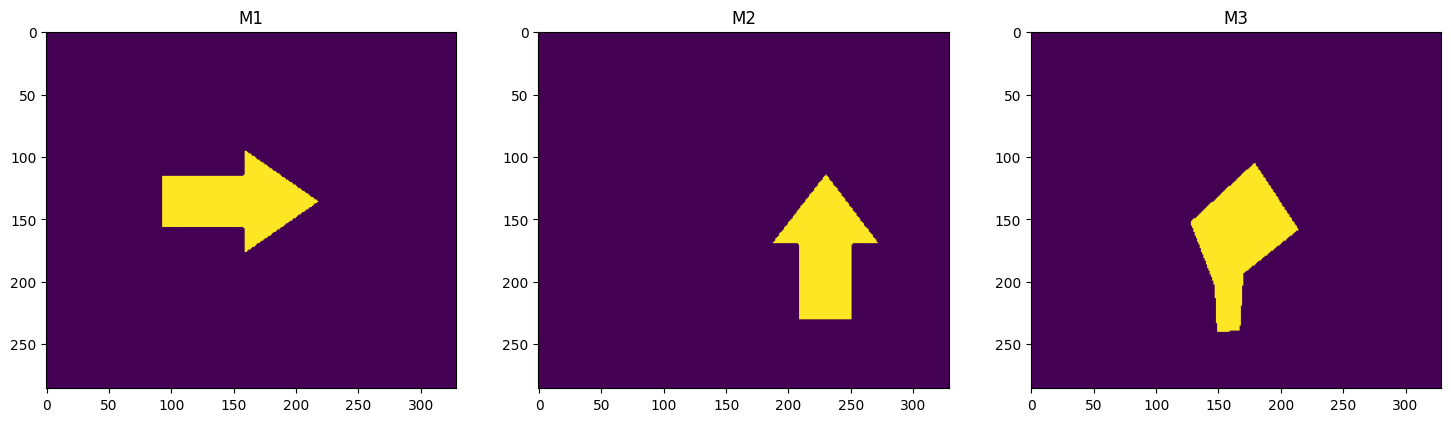

In [72]:
img1 = cv2.imread('lab_images/m1.png',0)
img2 = cv2.imread('lab_images/m2.png',0)
img3 = cv2.imread('lab_images/m3.png',0)

plt.figure(figsize=(18,6))
plt.subplot(131)
plt.imshow(img1)
plt.title("M1")
plt.subplot(132)
plt.imshow(img2)
plt.title("M2")
plt.subplot(133)
plt.imshow(img3)
plt.title("M3")
plt.show()


In [75]:
_, thresh1 = cv2.threshold(img1, 127, 255, 0)
_, thresh2 = cv2.threshold(img2, 127, 255, 0)
_, thresh3 = cv2.threshold(img3, 127, 255, 0)

# Contornos imagen 1
contours1, _ = cv2.findContours(thresh1, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cnt1 = contours1[0]

# Contornos imagen 2
contours2, _ = cv2.findContours(thresh2, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cnt2 = contours2[0]

# Contornos imagen 3
contours3, _ = cv2.findContours(thresh3, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cnt3 = contours3[0]


In [76]:
#https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gaf2b97a230b51856d09a2d934b78c015f

ret = cv2.matchShapes(cnt1,cnt1,cv2.CONTOURS_MATCH_I2,0)
print( "Diferencia de M1 con M1:  ",ret )
ret = cv2.matchShapes(cnt1,cnt2,cv2.CONTOURS_MATCH_I2,0)
print( "Diferencia de M1 con M2:  ",ret )
ret = cv2.matchShapes(cnt1,cnt3,cv2.CONTOURS_MATCH_I2,0)
print( "Diferencia de M1 con M3:  ",ret )

Diferencia de M1 con M1:   0.0
Diferencia de M1 con M2:   0.40899569722728557
Diferencia de M1 con M3:   3.202513551907042
